# Analysis Distillation

## Setup

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

df_all = pd.read_csv('../results/metrics/all_results.csv')
df_distil = df_all[df_all["label"].isin(["teacher_3B", "student_1B"])].copy()
df_quant  = df_all[df_all["label"].isin(["float32", "float16"])].copy()

with open("../results/metrics/teacher_3B.json") as f:
    teacher = json.load(f)

with open("../results/metrics/student_1B.json") as f:
    student = json.load(f)

teacher_itl = np.array(teacher["itl_per_position"])
student_itl = np.array(student["itl_per_position"])

print(f"Teacher ITL positions: {len(teacher_itl)}")
print(f"Student ITL positions: {len(student_itl)}")
print(f"\nTeacher peak ITL: {teacher_itl.max():.1f}ms at position {teacher_itl.argmax()}")
print(f"Student  peak ITL: {student_itl.max():.1f}ms at position {student_itl.argmax()}")

Teacher ITL positions: 300
Student ITL positions: 300

Teacher peak ITL: 252.2ms at position 230
Student  peak ITL: 56.7ms at position 107


## Speed Gap: TTFT and Throughput

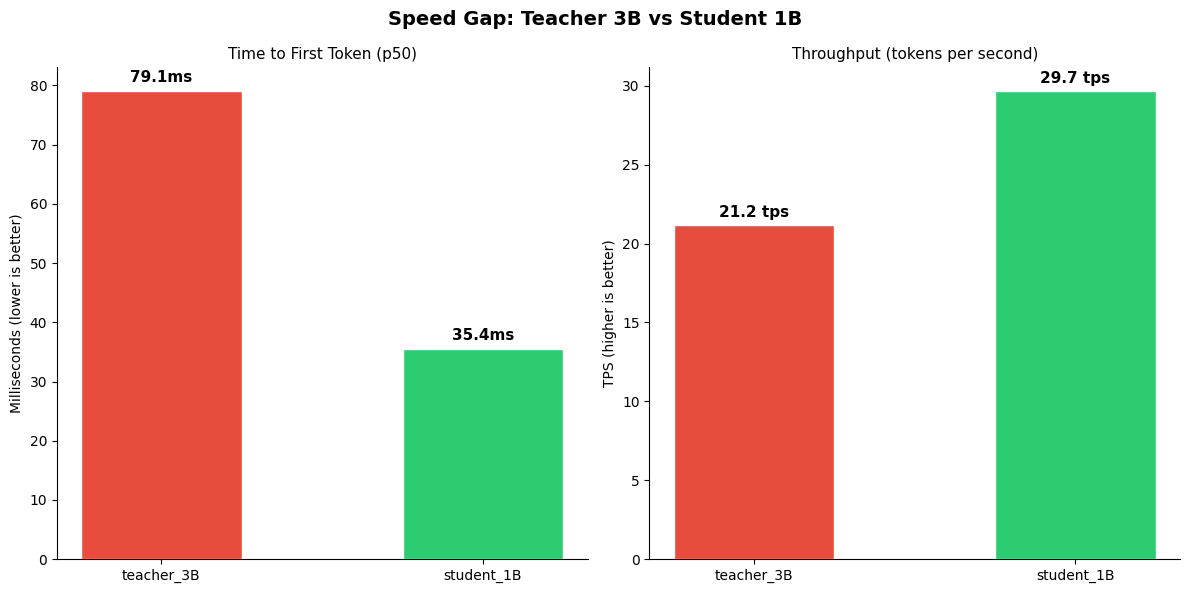

TTFT:       student is 2.23x faster
Throughput: student is 1.40x higher


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle("Speed Gap: Teacher 3B vs Student 1B", 
             fontsize=14, fontweight="bold")

labels = df_distil["label"].tolist()
colors = ["#e74c3c", "#2ecc71"]

# TTFT
ttft_vals = df_distil["ttft_p50_ms"].tolist()
bars = axes[0].bar(labels, ttft_vals, color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Time to First Token (p50)", fontsize=11)
axes[0].set_ylabel("Milliseconds (lower is better)")
for bar, val in zip(bars, ttft_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{val:.1f}ms",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

# Throughput
tps_vals = df_distil["throughput_tps"].tolist()
bars2 = axes[1].bar(labels, tps_vals, color=colors, width=0.5, edgecolor="white")
axes[1].set_title("Throughput (tokens per second)", fontsize=11)
axes[1].set_ylabel("TPS (higher is better)")
for bar, val in zip(bars2, tps_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val:.1f} tps",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/distillation/speed_gap.png", 
            dpi=300, bbox_inches="tight")
plt.show()

ttft_ratio = (df_distil[df_distil["label"]=="teacher_3B"]["ttft_p50_ms"].values[0] /
              df_distil[df_distil["label"]=="student_1B"]["ttft_p50_ms"].values[0])
tps_ratio  = (df_distil[df_distil["label"]=="student_1B"]["throughput_tps"].values[0] /
              df_distil[df_distil["label"]=="teacher_3B"]["throughput_tps"].values[0])

print(f"TTFT:       student is {ttft_ratio:.2f}x faster")
print(f"Throughput: student is {tps_ratio:.2f}x higher")

## Memory Gap

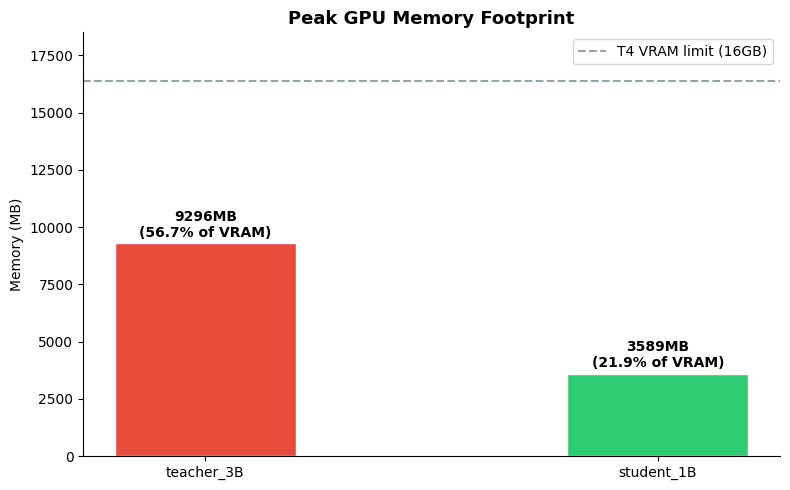

Teacher uses 2.59x more VRAM
Freed VRAM by choosing student: 5707MB (5.6GB)


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

mem_vals = df_distil["peak_memory_mb"].tolist()
bars = ax.bar(labels, mem_vals, color=colors, width=0.4, edgecolor="white")

ax.axhline(y=16384, color="#95a5a6", linestyle="--", 
           linewidth=1.5, label="T4 VRAM limit (16GB)")

for bar, val in zip(bars, mem_vals):
    pct = (val / 16384) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 150,
            f"{val:.0f}MB\n({pct:.1f}% of VRAM)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Peak GPU Memory Footprint", fontsize=13, fontweight="bold")
ax.set_ylabel("Memory (MB)")
ax.set_ylim(0, 18500)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/distillation/memory_gap.png", 
            dpi=150, bbox_inches="tight")
plt.show()

freed_mb  = mem_vals[0] - mem_vals[1]
print(f"Teacher uses {mem_vals[0]/mem_vals[1]:.2f}x more VRAM")
print(f"Freed VRAM by choosing student: {freed_mb:.0f}MB ({freed_mb/1024:.1f}GB)")

## ITL Per Position: Line Chart

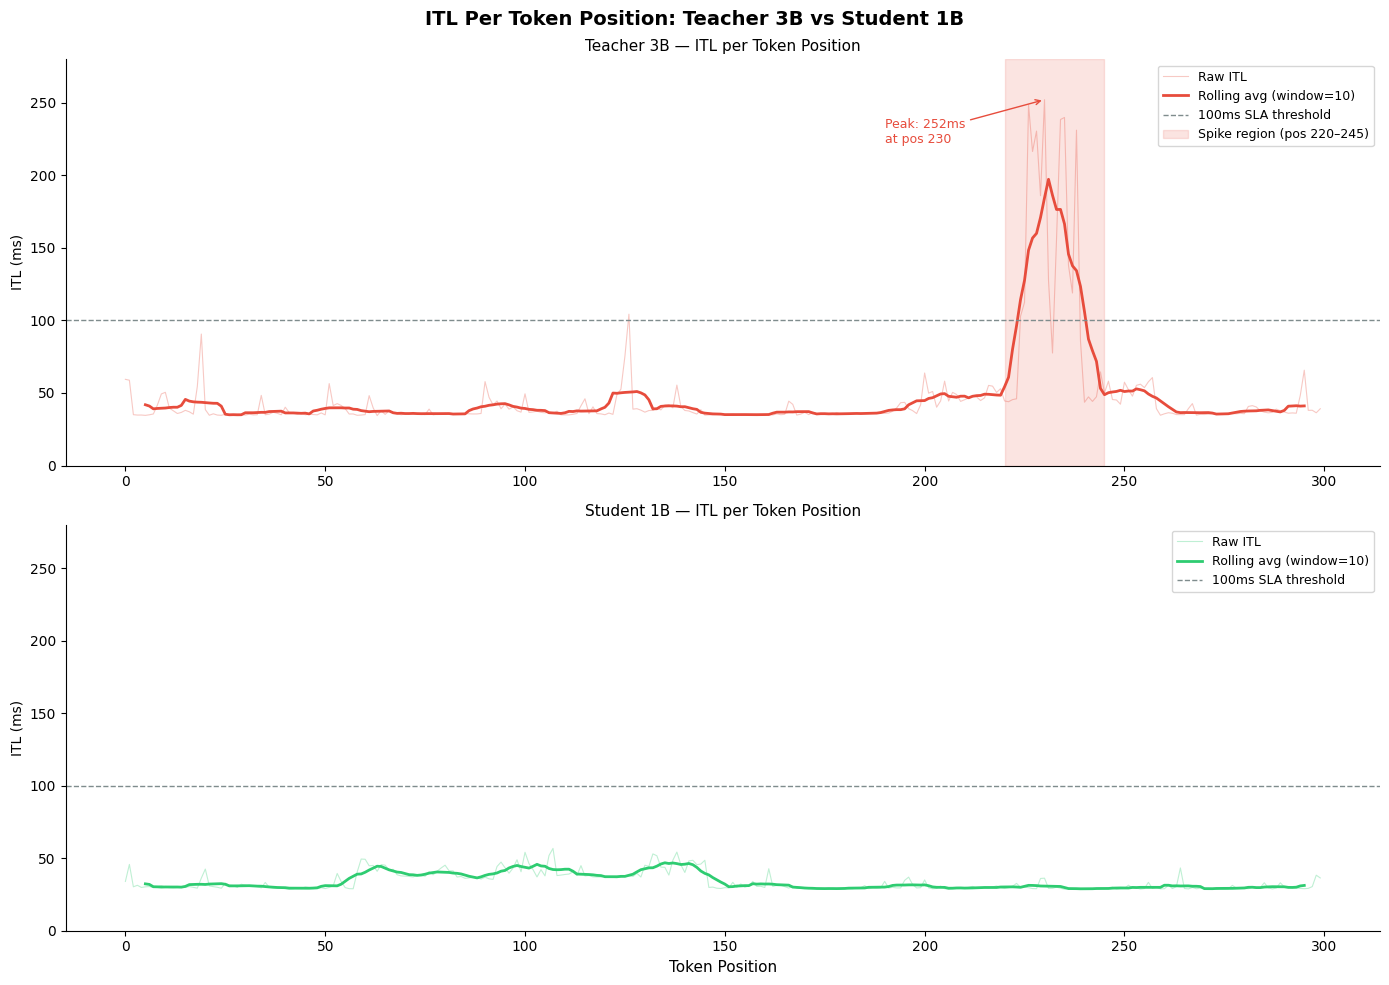

Teacher — mean: 47.2ms | max: 252.2ms | tokens above 100ms: 15
Student — mean: 33.7ms | max: 56.7ms | tokens above 100ms: 0


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
fig.suptitle("ITL Per Token Position: Teacher 3B vs Student 1B",
             fontsize=14, fontweight="bold")

positions = np.arange(len(teacher_itl))

window = 10
teacher_smooth = np.convolve(teacher_itl, 
                              np.ones(window)/window, mode='valid')
student_smooth = np.convolve(student_itl, 
                              np.ones(window)/window, mode='valid')

# Teacher
axes[0].plot(positions, teacher_itl, 
             color="#e74c3c", alpha=0.3, linewidth=0.8, label="Raw ITL")
axes[0].plot(np.arange(len(teacher_smooth)) + window//2, teacher_smooth,
             color="#e74c3c", linewidth=2, label=f"Rolling avg (window={window})")
axes[0].axhline(y=100, color="#7f8c8d", linestyle="--", 
                linewidth=1, label="100ms SLA threshold")

# Annotate spike region
spike_start = 220
spike_end   = 245
axes[0].axvspan(spike_start, spike_end, alpha=0.15, color="#e74c3c",
                label=f"Spike region (pos {spike_start}–{spike_end})")
axes[0].annotate(f"Peak: {teacher_itl.max():.0f}ms\nat pos {teacher_itl.argmax()}",
                 xy=(teacher_itl.argmax(), teacher_itl.max()),
                 xytext=(teacher_itl.argmax() - 40, teacher_itl.max() - 30),
                 fontsize=9, color="#e74c3c",
                 arrowprops=dict(arrowstyle="->", color="#e74c3c"))

axes[0].set_title("Teacher 3B — ITL per Token Position", fontsize=11)
axes[0].set_ylabel("ITL (ms)")
axes[0].set_ylim(0, 280)
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Student
positions_s = np.arange(len(student_itl))
axes[1].plot(positions_s, student_itl,
             color="#2ecc71", alpha=0.3, linewidth=0.8, label="Raw ITL")
axes[1].plot(np.arange(len(student_smooth)) + window//2, student_smooth,
             color="#2ecc71", linewidth=2, label=f"Rolling avg (window={window})")
axes[1].axhline(y=100, color="#7f8c8d", linestyle="--",
                linewidth=1, label="100ms SLA threshold")

axes[1].set_title("Student 1B — ITL per Token Position", fontsize=11)
axes[1].set_ylabel("ITL (ms)")
axes[1].set_ylim(0, 280)
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[1].set_xlabel("Token Position", fontsize=11)

plt.tight_layout()
plt.savefig("../results/figures/distillation/itl_per_position.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Stats
print(f"Teacher — mean: {teacher_itl.mean():.1f}ms | "
      f"max: {teacher_itl.max():.1f}ms | "
      f"tokens above 100ms: {(teacher_itl > 100).sum()}")
print(f"Student — mean: {student_itl.mean():.1f}ms | "
      f"max: {student_itl.max():.1f}ms | "
      f"tokens above 100ms: {(student_itl > 100).sum()}")

## Perplexity: Limitations or Constraint or Weakness or Not Fair

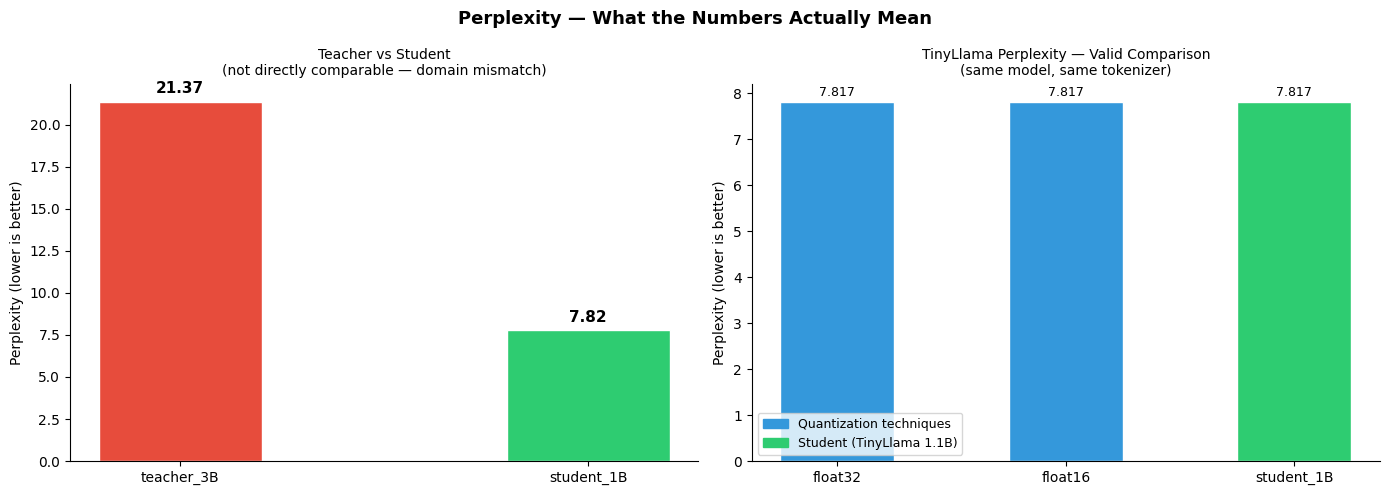

float16 baseline: 7.8173
student_1B:       7.8173
Difference:       0.0000 — identical, expected


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Perplexity — What the Numbers Actually Mean",
             fontsize=13, fontweight="bold")

# Panel kiri: teacher vs student dengan warning
labels_d = df_distil["label"].tolist()
ppl_d    = df_distil["perplexity"].tolist()

bars = axes[0].bar(labels_d, ppl_d,
                   color=["#e74c3c", "#2ecc71"],
                   width=0.4, edgecolor="white")
for bar, val in zip(bars, ppl_d):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val:.2f}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

axes[0].set_title("Teacher vs Student\n(not directly comparable — domain mismatch)",
                  fontsize=10)
axes[0].set_ylabel("Perplexity (lower is better)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Panel kanan: TinyLlama perplexity across quant — ini yang valid
valid_labels = df_quant["label"].tolist() + ["student_1B"]
valid_ppl    = df_quant["perplexity"].tolist() + [
    df_distil[df_distil["label"]=="student_1B"]["perplexity"].values[0]
]
valid_colors = ["#3498db"] * len(df_quant) + ["#2ecc71"]

bars2 = axes[1].bar(valid_labels, valid_ppl,
                    color=valid_colors, width=0.5, edgecolor="white")
for bar, val in zip(bars2, valid_ppl):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{val:.3f}",
                 ha="center", va="bottom", fontsize=9)

axes[1].set_title("TinyLlama Perplexity — Valid Comparison\n(same model, same tokenizer)",
                  fontsize=10)
axes[1].set_ylabel("Perplexity (lower is better)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

blue_patch  = mpatches.Patch(color="#3498db", label="Quantization techniques")
green_patch = mpatches.Patch(color="#2ecc71", label="Student (TinyLlama 1.1B)")
axes[1].legend(handles=[blue_patch, green_patch], fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig("../results/figures/distillation/perplexity_context.png",
            dpi=150, bbox_inches="tight")
plt.show()

float16_ppl = df_quant[df_quant["label"]=="float16"]["perplexity"].values[0]
student_ppl = df_distil[df_distil["label"]=="student_1B"]["perplexity"].values[0]
print(f"float16 baseline: {float16_ppl:.4f}")
print(f"student_1B:       {student_ppl:.4f}")
print(f"Difference:       {abs(student_ppl - float16_ppl):.4f} — identical, expected")